# **City Landscape in Sight: A Crowdsourced Framework for Unlocking Urban-Scale Window View Perceptions from Real Estate Imagery**

**Authors:** [Chucai Peng](https://ual.sg/author/chucai-peng/)†, [Sijie Yang](https://sijie-yang.com)†, Ang Liu, Yang Xiang, Zhixiang Zhou, [Filip Biljecki](https://filipbiljecki.com)* 

by [Urban Analytics Lab](https://ual.sg), [Department of Architecture](https://cde.nus.edu.sg/arch/), [College of Design and Engineering](https://cde.nus.edu.sg), [National University of Singapore](https://www.nus.edu.sg)


---

(† co-first authors, * corresponding authors)

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).

# Code_2_Image Pre-processing & Visual Feature Extraction

This notebook runs the image pre-processing pipeline and SVI-style color features for **training** and **inference** WVI folders (same layout under each root).

Pipeline (per dataset root):
1. **Pre-processing** (§1) — `masked.py` → `masked_cut.py` → `data_mini.py`: `WVI_Original/` → `WVI_Processed/`.
2. **Color features** (§2) — write to `data/training_features/Features.csv` or `data/inference_features/Features.csv`.

| Root | Processed images | Features table |
|------|------------------|----------------|
| `data/training_images/` | `WVI_Processed/` | `data/training_features/Features.csv` |
| `data/inference_images/` | `WVI_Processed/` | `data/inference_features/Features.csv` |

Then run **Code 1** (training labels) → **Code 3**.


## 0. Plotting Configuration

Run plotting configuration first — set up the overall style of figures.

In [1]:
import matplotlib as mpl
import seaborn as sns

sns.set_theme(context="paper", style="white", font_scale=0.9)

mpl.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "figure.autolayout": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "axes.linewidth": 0.6,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "legend.fontsize": 7,
    "legend.frameon": False,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(context="paper", style="white", font_scale=0.9)

INCH_PER_MM = 1.0 / 25.4
DOUBLE_COL_WIDTH = 183 * INCH_PER_MM
FIG_HEIGHT_SMALL = 2.2


def savefig_all(fig, basename, png_dpi=300, tight=True):
    out_base = Path(basename)
    out_base.parent.mkdir(parents=True, exist_ok=True)
    kwargs = {"bbox_inches": "tight", "pad_inches": 0.01} if tight else {}
    fig.savefig(str(out_base.with_suffix(".png")), dpi=png_dpi, **kwargs)
    fig.savefig(str(out_base.with_suffix(".svg")), **kwargs)


## 1. Image Pre-processing Pipeline (Original → Processed)

Each dataset root (`data/training_images/`, `data/inference_images/`) uses the same layout as `data/sample_images/`:

| Subfolder | Contents |
|-----------|----------|
| `WVI_Original/` | Raw listing photos (`{ID}.jpg`) |
| `WVI_Segmentation/` | Masks (`{ID}_mask.png`) |
| `WVI_Processed/` | Masked → cut → 256 px mini (`.jpg` or `.png`) |

Scripts: **`masked.py` → `masked_cut.py` → `data_mini.py`**. Work dirs `_work_masked/`, `_work_masked_cut/` live under each root.


In [3]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

SCRIPTS_DIR = Path("scripts").resolve()
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from masked import process_masked_directory
from masked_cut import process_masked_cut_directory
from data_mini import process_mini_directory

IMAGE_ROOTS: dict[str, Path] = {
    "training": Path("data/training_images"),
    "inference": Path("data/inference_images"),
}
FEATURES_CSV: dict[str, Path] = {
    "training": Path("data/training_features/Features.csv"),
    "inference": Path("data/inference_features/Features.csv"),
}
MAX_THUMB_SIZE = (256, 256)
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

# Backward-compatible aliases (training)
TRAINING_IMAGES_DIR = IMAGE_ROOTS["training"]
TRAIN_ORIGINAL_DIR = TRAINING_IMAGES_DIR / "WVI_Original"
TRAIN_SEGMENTATION_DIR = TRAINING_IMAGES_DIR / "WVI_Segmentation"
TRAIN_IMG_DIR = TRAINING_IMAGES_DIR / "WVI_Processed"
WORK_MASKED_DIR = TRAINING_IMAGES_DIR / "_work_masked"
WORK_MASKED_CUT_DIR = TRAINING_IMAGES_DIR / "_work_masked_cut"


def wvi_paths(images_root: Path) -> dict[str, Path]:
    """Standard WVI folder paths under a dataset root."""
    images_root = Path(images_root)
    return {
        "original_dir": images_root / "WVI_Original",
        "mask_dir": images_root / "WVI_Segmentation",
        "processed_dir": images_root / "WVI_Processed",
        "work_masked_dir": images_root / "_work_masked",
        "work_cut_dir": images_root / "_work_masked_cut",
    }


def list_images_in_dir(directory: Path, patterns: tuple[str, ...] = ("*.jpg", "*.jpeg", "*.png")) -> list[Path]:
    directory = Path(directory)
    paths: list[Path] = []
    for pat in patterns:
        paths.extend(directory.glob(pat))
    return sorted(paths, key=lambda p: p.stem)


def resolve_image_path(folder: Path, image_id: str, extensions: tuple[str, ...] = IMAGE_EXTENSIONS) -> Path:
    folder = Path(folder)
    for ext in extensions:
        path = folder / f"{image_id}{ext}"
        if path.exists():
            return path
    raise FileNotFoundError(f"No image for {image_id} under {folder}")


def run_original_to_processed(
    *,
    images_root: Path,
    label: str = "",
    max_size: tuple[int, int] = MAX_THUMB_SIZE,
) -> int:
    """masked → masked_cut → data_mini under ``images_root``."""
    paths = wvi_paths(images_root)
    tag = f"[{label}] " if label else ""
    for d in (paths["work_masked_dir"], paths["work_cut_dir"], paths["processed_dir"]):
        d.mkdir(parents=True, exist_ok=True)
    process_masked_directory(
        paths["original_dir"],
        paths["mask_dir"],
        paths["work_masked_dir"],
        desc=f"{tag}1/3 masked",
    )
    process_masked_cut_directory(
        paths["work_masked_dir"], paths["work_cut_dir"], desc=f"{tag}2/3 masked_cut"
    )
    n_out = process_mini_directory(
        paths["work_cut_dir"],
        paths["processed_dir"],
        max_size=max_size,
        desc=f"{tag}3/3 data_mini",
    )
    print(f"{tag}→ {n_out} images in {paths['processed_dir']}")
    return n_out


#### Run batch pipeline (`WVI_Original` → `WVI_Processed`)

Set `DATASETS_TO_PROCESS` to `("training",)`, `("inference",)`, or both. Requires `WVI_Original/` + `WVI_Segmentation/` under each root.


In [4]:
RUN_PREPROCESSING = True  # set False to skip re-writing WVI_Processed
DATASETS_TO_PROCESS = ("training", "inference")  # same layout under each root

if RUN_PREPROCESSING:
    for name in DATASETS_TO_PROCESS:
        root = IMAGE_ROOTS[name]
        paths = wvi_paths(root)
        print(f"\n=== {name}: {root.resolve()} ===")
        if not paths["original_dir"].is_dir():
            print(f"  skip — missing {paths['original_dir']}")
            continue
        if not paths["mask_dir"].is_dir():
            print(f"  skip — missing {paths['mask_dir']}")
            continue
        n_ids = len(list_images_in_dir(paths["original_dir"]))
        print(f"  preprocessing {n_ids} images …")
        run_original_to_processed(images_root=root, label=name)
    print("\nDone.")
else:
    print("Skipped preprocessing (RUN_PREPROCESSING=False).")


Preprocessing 499 images (masked → masked_cut → data_mini) …


1/3 masked:   0%|          | 0/499 [00:00<?, ?img/s]

[masked] 499 images → data/training_images/_work_masked


2/3 masked_cut:   0%|          | 0/499 [00:00<?, ?img/s]

[masked_cut] 499 images → data/training_images/_work_masked_cut


3/3 data_mini:   0%|          | 0/499 [00:00<?, ?img/s]

[data_mini] 499 images → data/training_images/WVI_Processed
Done.


#### Preview pre-processed images

Set `PREVIEW_DATASET` to `"training"` or `"inference"`.


WVI_Processed: 499 images


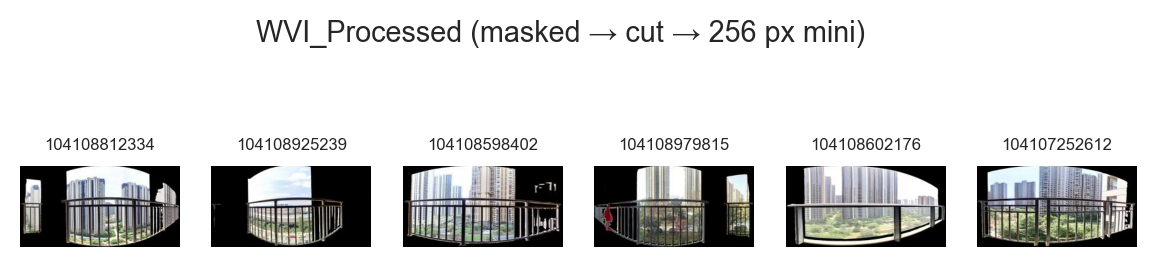

In [5]:
PREVIEW_DATASET = "training"  # or "inference"
preview_dir = wvi_paths(IMAGE_ROOTS[PREVIEW_DATASET])["processed_dir"]

image_paths = list_images_in_dir(preview_dir)
print(f"[{PREVIEW_DATASET}] WVI_Processed: {len(image_paths)} images")

n_show = 6
rng = np.random.default_rng(42)
sample = rng.choice(image_paths, size=min(n_show, len(image_paths)), replace=False)

fig, axes = plt.subplots(1, n_show, figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_SMALL))
for ax, p in zip(axes, sample):
    ax.imshow(Image.open(p))
    ax.set_title(p.stem, fontsize=6)
    ax.axis("off")
fig.suptitle(f"WVI_Processed [{PREVIEW_DATASET}] (masked → cut → 256 px mini)", y=0.92)
savefig_all(fig, f"figures/code2_{PREVIEW_DATASET}_image_preview")
plt.show()


## 2. Color Feature Extraction (standalone)

**Run this section alone** — execute the code cell below (helpers + `color()`), then the batch cell. No §0–§1 required.

Writes `data/training_features/Features.csv` and/or `data/inference_features/Features.csv` from each root's `WVI_Processed/` (`.jpg` or `.png`). Set `DATASETS_FOR_FEATURES` accordingly.


In [12]:
import os
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from PIL import Image
from scipy.stats import entropy as shannon_entropy
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


IMAGE_ROOTS: dict[str, Path] = {
    "training": Path("data/training_images"),
    "inference": Path("data/inference_images"),
}
FEATURES_CSV: dict[str, Path] = {
    "training": Path("data/training_features/Features.csv"),
    "inference": Path("data/inference_features/Features.csv"),
}
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")


def wvi_paths(images_root: Path) -> dict[str, Path]:
    images_root = Path(images_root)
    return {
        "original_dir": images_root / "WVI_Original",
        "mask_dir": images_root / "WVI_Segmentation",
        "processed_dir": images_root / "WVI_Processed",
        "work_masked_dir": images_root / "_work_masked",
        "work_cut_dir": images_root / "_work_masked_cut",
    }


def list_images_in_dir(directory: Path, patterns: tuple[str, ...] = ("*.jpg", "*.jpeg", "*.png")) -> list[Path]:
    directory = Path(directory)
    paths: list[Path] = []
    for pat in patterns:
        paths.extend(directory.glob(pat))
    return sorted(paths, key=lambda p: p.stem)


def resolve_image_path(folder: Path, image_id: str, extensions: tuple[str, ...] = IMAGE_EXTENSIONS) -> Path:
    folder = Path(folder)
    for ext in extensions:
        path = folder / f"{image_id}{ext}"
        if path.exists():
            return path
    raise FileNotFoundError(f"No image for {image_id} under {folder}")

COLOR_FEATURE_COLUMNS = [
    "Colorfulness",
    "Canny_Edges",
    "Hue_Mean",
    "Hue_Std",
    "Saturation_Mean",
    "Saturation_Std",
    "Lightness_Mean",
    "Lightness_Std",
    "Contrast",
    "Sharpness",
    "Entropy",
    "Image_Variance",
]


def read_image_with_pil(image_path: str) -> np.ndarray:
    """Read an image with PIL and return an OpenCV BGR array."""
    try:
        pil_image = Image.open(image_path).convert("RGB")
        image = np.array(pil_image)
        return cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    except Exception as e:
        raise ValueError(f"Failed to read the image with PIL: {e}") from e


def compute_colorfulness(image: np.ndarray) -> float:
    (B, G, R) = cv2.split(image.astype("float"))
    rg = np.absolute(R - G)
    yb = np.absolute(0.5 * (R + G) - B)
    rb_mean, rb_std = np.mean(rg), np.std(rg)
    yb_mean, yb_std = np.mean(yb), np.std(yb)
    std_root = np.sqrt(rb_std ** 2 + yb_std ** 2)
    mean_root = np.sqrt(rb_mean ** 2 + yb_mean ** 2)
    return float(std_root + 0.3 * mean_root)


def compute_canny_edges(image: np.ndarray) -> float:
    edges = cv2.Canny(image, 100, 200)
    return float(np.sum(edges) / edges.size)


def compute_hue_mean_std(image: np.ndarray) -> tuple[float, float]:
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hue = hsv_image[:, :, 0]
    return float(np.mean(hue)), float(np.std(hue))


def compute_saturation_mean_std(image: np.ndarray) -> tuple[float, float]:
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    saturation = hsv_image[:, :, 1]
    return float(np.mean(saturation)), float(np.std(saturation))


def compute_lightness_mean_std(image: np.ndarray) -> tuple[float, float]:
    lab_image = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)
    lightness = lab_image[:, :, 0]
    return float(np.mean(lightness)), float(np.std(lightness))


def compute_contrast(image: np.ndarray) -> float:
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return float(gray_image.std())


def compute_sharpness(image: np.ndarray) -> float:
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return float(cv2.Laplacian(gray_image, cv2.CV_64F).var())


def compute_entropy(image: np.ndarray) -> float:
    """Shannon entropy of the grayscale intensity histogram (bits).

    ``scipy.stats.entropy`` must be applied to a 1-D probability vector. Passing a
    2-D ``(H, W)`` array computes entropy **per column**; all-black columns (common
    after window masking) yield ``nan``, which then propagates via ``np.mean``.
    """
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    pixels = gray_image.ravel()
    pixels = pixels[pixels > 0]  # ignore masked-out black padding
    if pixels.size == 0:
        return 0.0
    hist, _ = np.histogram(pixels, bins=256, range=(1, 256))
    pk = hist.astype(np.float64)
    total = pk.sum()
    if total == 0:
        return 0.0
    pk = pk / total
    return float(shannon_entropy(pk))


def compute_image_variance(image: np.ndarray) -> float:
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return float(np.var(gray_image))


def extract_features(image_path: str) -> dict[str, float]:
    """Extract all basic color / low-level features from one image."""
    image = read_image_with_pil(image_path)
    hue_mean, hue_std = compute_hue_mean_std(image)
    saturation_mean, saturation_std = compute_saturation_mean_std(image)
    lightness_mean, lightness_std = compute_lightness_mean_std(image)
    return {
        "Colorfulness": compute_colorfulness(image),
        "Canny_Edges": compute_canny_edges(image),
        "Hue_Mean": hue_mean,
        "Hue_Std": hue_std,
        "Saturation_Mean": saturation_mean,
        "Saturation_Std": saturation_std,
        "Lightness_Mean": lightness_mean,
        "Lightness_Std": lightness_std,
        "Contrast": compute_contrast(image),
        "Sharpness": compute_sharpness(image),
        "Entropy": compute_entropy(image),
        "Image_Variance": compute_image_variance(image),
    }


def color(
    df: pd.DataFrame,
    folder_path: str | os.PathLike | None = None,
    id_column: str = "ID",
    image_ext: str = ".jpg",
) -> pd.DataFrame:
    """Extract color features for each row and append as new columns.

    Expects `id_column` to hold the image stem (e.g. ``104109103352``); files are
    resolved as ``{folder_path}/{ID}{image_ext}``.
    """
    if folder_path is None:
        raise ValueError("folder_path must be provided")

    feature_rows: list[dict[str, float]] = []
    nan_row = {k: np.nan for k in COLOR_FEATURE_COLUMNS}

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting color features"):
        image_path = resolve_image_path(Path(folder_path), str(row[id_column]))
        try:
            feature_rows.append(extract_features(image_path))
        except Exception as e:
            print(f"\nError processing {image_path}: {e}")
            feature_rows.append(nan_row.copy())

    return pd.concat([df.reset_index(drop=True), pd.DataFrame(feature_rows)], axis=1)


# SVI column names → Features.csv schema (Code 3 / legacy tables)
COLOR_TO_FEATURES_COLUMN = {
    "Hue_Mean": "Hue_Mean",
    "Hue_Std": "Hue_Std",
    "Saturation_Mean": "Saturation_Mean",
    "Saturation_Std": "Saturation_Std",
    "Lightness_Mean": "Brightness_Mean",
    "Lightness_Std": "Brightness_Std",
    "Canny_Edges": "EdgePixelRatio",
    "Entropy": "Entropy",
}
EXTRA_COLOR_COLUMNS = ["Colorfulness", "Contrast", "Sharpness", "Image_Variance"]


def color_features_for_features_table(color_df: pd.DataFrame) -> pd.DataFrame:
    """Rename / select color columns for Features.csv."""
    out = color_df[["ID"]].copy()
    out["ID"] = out["ID"].astype(str)
    for src, dst in COLOR_TO_FEATURES_COLUMN.items():
        out[dst] = color_df[src].values
    for col in EXTRA_COLOR_COLUMNS:
        out[col] = color_df[col].values
    return out


def write_color_to_features_csv(
    color_df: pd.DataFrame,
    features_path: str | os.PathLike,
) -> pd.DataFrame:
    """Merge extracted color features into Features.csv (preserve other columns)."""
    features_path = Path(features_path)
    color_part = color_features_for_features_table(color_df)
    update_cols = [c for c in color_part.columns if c != "ID"]

    if features_path.exists():
        base = pd.read_csv(features_path)
        base["ID"] = base["ID"].astype(str)
        base = base.drop(columns=[c for c in update_cols if c in base.columns], errors="ignore")
        merged = base.merge(color_part, on="ID", how="outer")
        # Prefer freshly extracted color values when both sides have data
        for col in update_cols:
            if col in merged.columns:
                pass  # already from color_part via merge
    else:
        merged = color_part

    # Stable column order: ID first, then legacy order if file existed, append any new cols
    cols = ["ID"] + [c for c in merged.columns if c != "ID"]
    merged = merged[cols]
    features_path.parent.mkdir(parents=True, exist_ok=True)
    merged.to_csv(features_path, index=False)
    return merged


In [13]:
# --- §2 bootstrap (no §0–§1 required) ---
from pathlib import Path

import pandas as pd

RUN_COLOR_FEATURES = True
DATASETS_FOR_FEATURES = ("inference",)  # trailing comma required for one item; ("inference") is a str

if RUN_COLOR_FEATURES:
    for name in DATASETS_FOR_FEATURES:
        root = IMAGE_ROOTS[name]
        paths = wvi_paths(root)
        processed_dir = paths["processed_dir"]
        features_path = FEATURES_CSV[name]
        features_path.parent.mkdir(parents=True, exist_ok=True)

        print(f"\n=== {name}: color features ===")
        if not processed_dir.is_dir():
            print(f"  skip — missing {processed_dir}")
            continue

        image_paths = list_images_in_dir(processed_dir)
        if not image_paths:
            print(f"  skip — no images in {processed_dir}")
            continue

        id_df = pd.DataFrame({"ID": [p.stem for p in image_paths]})
        print(f"  extracting {len(id_df)} images from {processed_dir} …")
        color_df = color(id_df, folder_path=str(processed_dir), id_column="ID")
        features_df = write_color_to_features_csv(color_df, features_path)
        print(f"  wrote {len(features_df)} rows × {len(features_df.columns)} cols → {features_path.resolve()}")

        sample_id = id_df["ID"].iloc[0]
        sample_feats = extract_features(str(resolve_image_path(processed_dir, sample_id)))
        print(f"  sample {sample_id}: Entropy={sample_feats['Entropy']:.4f}")
else:
    print("Skipped color features (RUN_COLOR_FEATURES=False).")



=== inference: color features ===
  extracting 12334 images from data/inference_images/WVI_Processed …


Extracting color features:   0%|          | 0/12334 [00:00<?, ?it/s]

  wrote 12334 rows × 25 cols → /Users/sijieyang/Documents/GitHub/City-Landscape-In-Sight/data/inference_features/Features.csv
  sample 104100497645: Entropy=5.0157


**Summary.** Code 2 runs mask → cut → mini and SVI color features for `data/training_images/` and `data/inference_images/` (same WVI folder layout). Training features → `data/training_features/Features.csv`; inference → `data/inference_features/Features.csv`. Then **Code 1** + **Code 3**.
